In [25]:
import numpy as np
import math
import matplotlib.pyplot as plt

Use numpy for representing the hamiltonian to begin with, and possibly use qutip or qiskit later as a higher-level representation.

The entire process of getting to the final Hamiltonian (represented as $c_1 Z + c_2 X$) can roughly be described as:
1. H2 geometry
2. basis set (STO-3G)
3. one/two electron integrals
4. second-quantized Hamiltonian
5. Jordan-Wigner transformation
6. 4-qubit Pauli Hamiltonian
7. symmetry reduction / tapering
8. 1-qubit Hamiltonian
9. final representation

Of course, we could just:

In [26]:
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j,  0]], dtype=complex)
Z = np.array([[1,  0], [0, -1]], dtype=complex)

c1 = 0.78796736
c2 = 0.18128881

H = c1 * Z + c2 * X

But that's not fun. Instead, start with the electronic structure:

### $H_2$ geometry

2 hydrogen nuclei separated by some distance $R$ (in the paper, they use equilibrium geometry with a distance of 0.7414 Å)

In [31]:
R_angstrom = 0.7414
R = R_angstrom * 1.8897259886

Note that we're converting to bohr, because later formulas will naturally use atomic units.

The next step introduces the STO-3G basis (slater-type orbital approximated by three gaussian-type orbitals). Mathematically:
$$
\mathcal{X}_\mu(r)= \sum_{p=1}^3 d_{\mu p}g_{\mu p}(r)
$$

(where $g$ is a gaussian function centered on the nucleus)

Each spatial orbital can have 2 spin states, resulting in a total of 4 spin orbitals (also 4 qubits).

(probably needs a more in depth explanation of STO-3G)

Hydrogen uses only one basis function $1s$

$$
\mathcal{X}_{1s} = c_1 G(\alpha_1) + c_2 G(\alpha_2) + c_3 G(\alpha_3)
$$

$$
G(\alpha, r) = N\mathrm{e}^{-\alpha r^2}
$$

where $N$ is the normalization constant. For an s-type gaussian in 3D:

$$
N = \left( \frac{2\alpha}{\pi}^{3/4} \right)
$$

The following are the actual values of the coefficients and exponents for the $1s$ basis set:

In [28]:
exponents = [2.22766, 0.405771, 0.109818]
coefficients = [0.154329, 0.535328, 0.444635]

N_constant = lambda a: ((2 * a) / math.pi)**0.75

primitive_gaussian = lambda a, r: N_constant(a) * math.exp(-a * r**2)

def sto3g_1s(r):
    value = 0.0

    for a, c in zip(exponents, coefficients):
        value += c * primitive_gaussian(a, r)

    return value

Now we define the two hydrogen centres (our corresponding to two values of R) and evaluate the orbital at different values, by calculating the distance from each nucleus and evaluating the basis function centered on each H. This is also known as LCAO (Linear Combination of Atomic Orbitals).

In [29]:
RA = -R / 2
RB = R / 2

x_values = np.linspace(-3, 3, 500)

psi_values = []

for x in x_values:

    rA = abs(x - RA)
    rB = abs(x - RB)

    phi_A = sto3g_1s(rA)
    phi_B = sto3g_1s(rB)

    psi = phi_A + phi_B

    psi_values.append(psi)

Let's try plotting the molecular orbital now, with `matplotlib`:

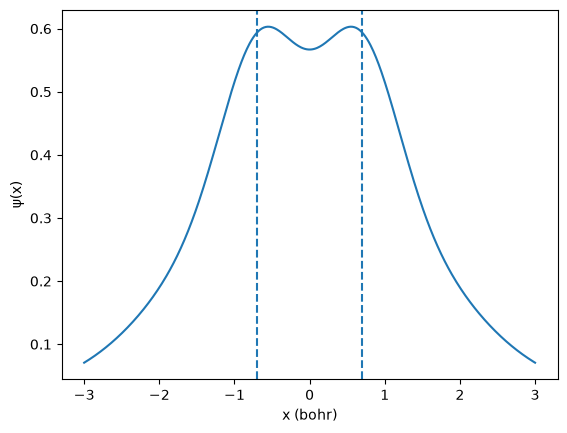

In [30]:
plt.plot(x_values, psi_values)

plt.axvline(RA, linestyle="--")
plt.axvline(RB, linestyle="--")

plt.xlabel("x (bohr)")
plt.ylabel("ψ(x)")
plt.show()